In [1]:
import numpy as np
import os
import pandas as pd
from netCDF4 import Dataset
import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib.colors import BoundaryNorm, ListedColormap, LinearSegmentedColormap
from matplotlib import gridspec
import itertools as it
from utils.analysis import uq_get_obs
from sklearn.preprocessing import StandardScaler
from sklearn_extra.cluster import KMedoids
from sklearn.metrics import silhouette_score
from tqdm import tqdm
from scipy.stats import ttest_ind
import pickle


rcParams['font.size'] = 12
rcParams['axes.titlesize'] = 12

pft_names = ['Spruce', 'Tamarack', 'Shrub']
pft_frac = [0.36, 0.14, 0.25, 0.25]

outdir = os.path.join(os.environ['PROJDIR'], 'ELM_Phenology', 'output', 'extract')

chambers_ordered = {
    'amb': ['7', '6', '20', '13', '8', '17'],
    'elev': ['19', '11', '4', '16', '10']
}

labs = 'abcdefghijklmnopqrstuvwxyz'

prefix_list = ['UQ_20231118', 'UQ_20240107', 'UQ_20240112'] # , 'UQ_20240312_test20241017']
name_list = ['ELM-OLD$_{optim}$_ENS', 'ELM-MYCI_ENS', 'ELM-MYCI$_{optim}$_ENS']
color_list = ['#1b249e', '#ffa500', '#ff0000']
subset_ensemble_best = [3067, 1485, 1944]
#subset_ensemble_best = [1181, 2786, 1944]
subset_ensemble = {'UQ_20231118': [1903,823,2598,2028,3796,3165,2526,2691,3453,1534,3108,2472,231,
                                   1196,907,3620,1181,262,2848,3613,3067,2562,1125,1757,1679,1682,
                                   2154,98,1103,3003,694,3661,652,709,3711,255,1660,3767,3564,
                                   1130], 
                   'UQ_20240107': [249,2702,61,936,174,1535,1485,1002,3119,1741,2263,1081,1590,103,
                                 1918,2786,2541,1532,559,1685,902,1026,1392,1881,1377,316,722,1069,
                                 1957,131,1198,1027,616,2120,1963,3384,3510,1847,653,3203], 
                   'UQ_20240112': [1944,2204,1429,2540,2764,867,654,1870,1079,1362,2922,1330,448,
                                   2364, 2601,2165,2421,3609,3554,34,1172,1480,161,1980,2259,840,
                                   3116,1071, 3744,1372,2495,2096,3204,55,3726,3297,2971,1838,1002,
                                   3650]}

In [2]:
##########################################################################
# Collect the parameter values
##########################################################################
def get_par_list(prefix):
    parm_file = os.path.join(f'./calibration_files/parm_file_{prefix.replace("UQ_","")}')
    par_vars = []
    with open(parm_file) as f:
        for line in f:
            if line != '\n' and line[0] != '#':
                line = line.split()
                par_vars.append(line)
    par_vars = pd.DataFrame(np.array(par_vars), columns = ['par_name', 'pft', 'min', 'max'])
    par_vars['pft'] = par_vars['pft'].astype(int)
    par_vars['min'] = par_vars['min'].astype(np.float32)
    par_vars['max'] = par_vars['max'].astype(np.float32)
    par_vars = par_vars.set_index(['par_name', 'pft'])
    return par_vars

def get_params(prefix, par_list):
    ens_ids = range(1, 4001)
    results = pd.DataFrame(np.nan, index = ens_ids, columns = par_list.index)

    for ens_id in ens_ids:
        folder = os.path.join(os.environ['E3SM_ROOT'], 'output', 'UQ', 
                            f'{prefix}_US-SPR_ICB20TRCNPRDCTCBC', f"g{ens_id:05d}")
        filepath = os.path.join(folder, f"clm_params_{ens_id:05d}.nc")
        ds = Dataset(filepath, 'r')
        for par,pft in par_list.index:
            arr = np.array(ds.variables[par][:]).squeeze()
            if arr.ndim == 0 or arr.size == 1:
                results.loc[ens_id, (par, 0)] = float(arr)
            elif arr.size == 25:
                for pft in [2,3,11]:
                    results.loc[ens_id, (par, pft)] = float(arr[pft])
        ds.close()

    return results

def get_default_params(par_list):
    results = pd.Series(np.nan, index = par_list.index)
    filepath = os.path.join(os.environ['E3SM_ROOT'], 'inputdata', 'atm', 'datm7',
                            'CLM1PT_data', 'SPRUCE_data', 
                            'clm_params_SPRUCE_20231120_spruceroot.nc_CNP')
    ds = Dataset(filepath, 'r')
    for par,pft in par_list.index:
        arr = np.array(ds.variables[par][:]).squeeze()
        if arr.ndim == 0 or arr.size == 1:
            results.loc[(par, 0)] = float(arr)
        elif arr.size == 25:
            for pft in [2,3,11]:
                results.loc[(par, pft)] = float(arr[pft])
    ds.close()
    return results


parvals_collect = {}
for i, prefix in enumerate(prefix_list):
    par_list = get_par_list(prefix)
    results = get_params(prefix, par_list)

    normed = pd.DataFrame(np.nan, index = results.index, columns = results.columns)
    for ind in par_list.index:
        normed.loc[:, ind] = (results.loc[:, ind].values - par_list.loc[ind, 'min']) / \
            (par_list.loc[ind, 'max'] - par_list.loc[ind, 'min'])
    parvals_collect[prefix] = normed.sort_index(axis = 1).dropna(how = 'all', axis = 1)

# Add the default model's parameter set
par_list = get_par_list('UQ_20231118')
parvals_default = get_default_params(par_list)
for ind in par_list.index:
    parvals_default.loc[ind] = (parvals_default.loc[ind] - par_list.loc[ind, 'min']) / \
        (par_list.loc[ind, 'max'] - par_list.loc[ind, 'min'])
parvals_default = parvals_default.loc[par_list.index].sort_index()

In [3]:
##########################################################################
# Collect the model outputs
##########################################################################
# the dimensions are:
#   N sims x VAR_LIST x (amb, elev) x (mean, mean_std, slope, ts * slope_std)
N_list = [4000, 4000, 4000]
BLOCK_LIST = [200, 200, 200]
VAR_LIST = ['AGBiomass_Spruce', 'AGBiomass_Tamarack', 'AGBiomass_Shrub',
            'AGNPPtoBiomass_Spruce', 'AGNPPtoBiomass_Tamarack', 'AGNPPtoBiomass_Shrub',
            'AGNPP_Spruce', 'AGNPP_Tamarack', 'AGNPP_Shrub', 'NPP_moss',
            'BGNPP_TreeShrub', 'BGtoAG_TreeShrub', 'NPP', 'HR', 'NEE']
VAR_SUBSET =  ['AGNPP_Spruce','AGNPP_Tamarack','AGNPP_Shrub', 'NPP_moss',
               'BGNPP_TreeShrub','NPP','HR']
xticklabels = [var.replace('_','$_{')+'}$' for var in VAR_SUBSET[:5]] + \
              [var.replace('_',' ') for var in VAR_SUBSET[5:]]
ind_list = [] # the index to VAR_SUBSET that we are interested in
for i,var in enumerate(VAR_LIST):
    if var in VAR_SUBSET:
        ind_list.append(i)
ind_list = np.array(ind_list)

# Get observed values
collection_obs = uq_get_obs(VAR_LIST).loc[VAR_SUBSET, :]

# Get simulated values
collect_sims = {}
for N, BLOCK, prefix in zip(N_list, BLOCK_LIST, prefix_list):
    collect = np.empty([N, len(VAR_LIST), 2, 4], float)
    for b in range(0, N // BLOCK):
        collect[(b*BLOCK):((b + 1)*BLOCK), :, :, :] = np.load(os.path.join(
            os.environ['PROJDIR'], 'ELM_Phenology', 'output', "extract", prefix,
            f"ensemble_collection_part{b:03g}.bin"), allow_pickle=True)[:, 1:, :, :] # TEMPORARY
    # convert Inf's to NaN
    collect = np.where(~((collect == np.inf) | (collect == -np.inf)), collect, np.nan)
    # revert the signs of NEE & HR to be compatible with Paul's data
    # collect[:, -3:-1, :, :] = - collect[:, -3:-1, :, :]
    # TEMPORARY
    collect[:, -2:, :, :] = - collect[:, -2:, :, :]

    collect_sims[(prefix, 'mean', 'aco2')] = collect[:, :, :, 0][:, ind_list, 0]
    collect_sims[(prefix, 'mean', 'eco2')] = collect[:, :, :, 0][:, ind_list, 1]
    collect_sims[(prefix, 'slope', 'aco2')] = collect[:, :, :, 2][:, ind_list, 0]
    collect_sims[(prefix, 'slope', 'eco2')] = collect[:, :, :, 2][:, ind_list, 1]

    ### Normalize the simulated values using the observed values
    ## This results in little separation between clusters
    ##collect_sims[(prefix, 'mean', 'aco2')] = collect_sims[(prefix, 'mean', 'aco2')] / \
    ##    collection_obs.loc[(slice(None), 'amb'), 'mean'].values.reshape(1,-1)
    ##collect_sims[(prefix, 'mean', 'eco2')] = collect_sims[(prefix, 'mean', 'eco2')] / \
    ##    collection_obs.loc[(slice(None), 'elev'), 'mean'].values.reshape(1,-1)
    ##collect_sims[(prefix, 'slope', 'aco2')] = collect_sims[(prefix, 'slope', 'aco2')] / \
    ##    collection_obs.loc[(slice(None), 'amb'), 'slope'].values.reshape(1,-1)
    ##collect_sims[(prefix, 'slope', 'eco2')] = collect_sims[(prefix, 'slope', 'eco2')] / \
    ##    collection_obs.loc[(slice(None), 'elev'), 'slope'].values.reshape(1,-1)

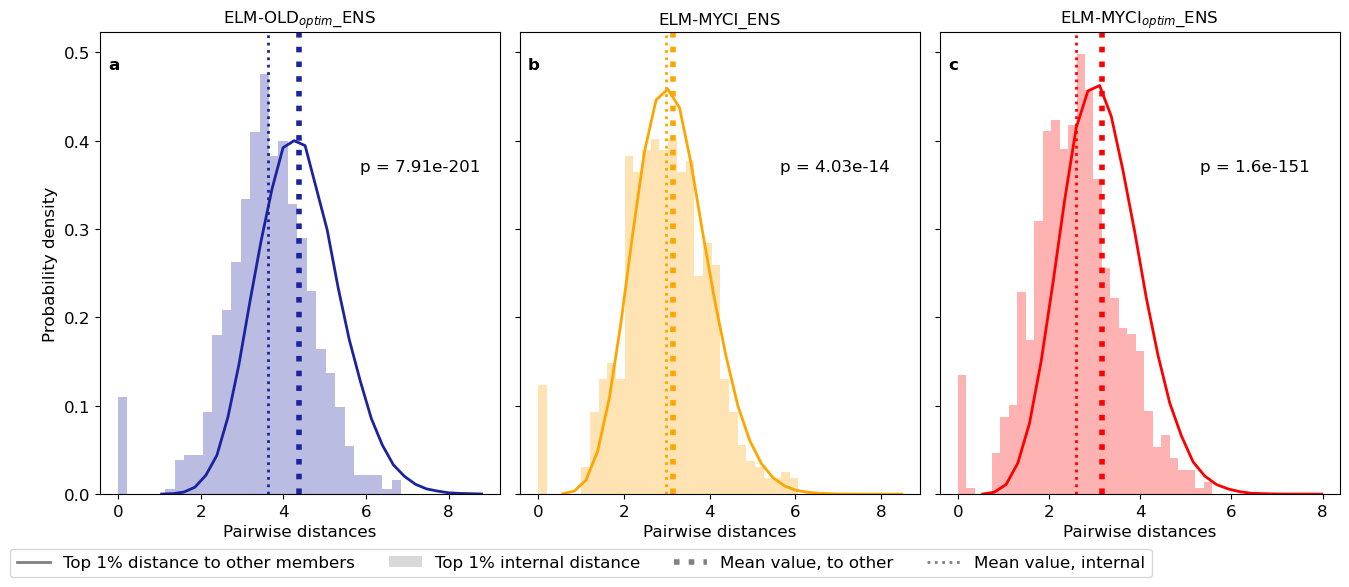

In [ ]:
##########################################################################
# Plot the probability distributions of the pairwise Euclidean distances of 
# the parameters of the ensemble members.
##########################################################################
euclid_distances = {}
euclid_distances_top = {}
for i, prefix in enumerate(prefix_list):
    X1 = parvals_collect[prefix].drop(subset_ensemble[prefix], axis = 0).values
    X2 = parvals_collect[prefix].loc[subset_ensemble[prefix], :].values

    # between the top 20 ensemble members and the rest
    AA = np.sum(X1**2, axis=1)  # shape: (d1,)
    BB = np.sum(X2**2, axis=1)  # shape: (d2,)
    cross = np.dot(X1, X2.T)
    # Compute the squared distances using broadcasting
    # dist_sq[i, j] = ||A[:, i] - B[:, j]||^2 = AA[i] + BB[j] - 2 * cross[i, j]
    dist_sq = AA[:, np.newaxis] + BB[np.newaxis, :] - 2 * cross
    euclid_distances[prefix] = dist_sq

    # among the top 20 ensemble members
    norms = np.sum(X2**2, axis=1)
    dist_sq = norms[:, np.newaxis] + norms[np.newaxis, :] - 2 * np.dot(X2, X2.T)
    euclid_distances_top[prefix] = dist_sq

fig, axes = plt.subplots(1, 3, figsize = (16, 6), sharey = True)
fig.subplots_adjust(wspace = 0.05)
for i, prefix in enumerate(prefix_list):
    ax = axes.flat[i]

    X1 = euclid_distances[prefix].reshape(-1)
    X2 = euclid_distances_top[prefix].reshape(-1)

    counts, bin_edges = np.histogram(X1, bins=30, density=True)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    ax.plot(bin_centers, counts, color = color_list[i], lw = 2)
    ax.axvline(np.mean(X1), lw = 4, ls = ':', color = color_list[i])

    counts, bin_edges = np.histogram(X2, bins=30, density=True)
    bin_diff = np.diff(bin_edges)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    bar = ax.bar(bin_centers, counts, color = color_list[i], alpha = 0.3, width = bin_diff)
    ax.axvline(np.mean(X2), lw = 2, ls = ':', color = color_list[i])

    ax.set_title(name_list[i])

    t_stat, p_value = ttest_ind(X1, X2)

    ax.text(0.65, 0.7, f'p = {p_value:.3g}', transform = ax.transAxes)
    ax.text(0.02, 0.92, labs[i], fontdict = {'weight': 'bold'}, transform = ax.transAxes)
    ax.set_xlabel('Pairwise distances')
    if i == 0:
        ax.set_ylabel('Probability density')

h, = ax.plot(np.nan, np.nan, color = 'gray', lw = 2)
bar = ax.bar(np.nan, np.nan, color = 'gray', alpha = 0.3)
h3 = ax.axvline(np.nan, lw = 4, ls = ':', color = 'gray')
h4 = ax.axvline(np.nan, lw = 2, ls = ':', color = 'gray')
ax.legend([h, bar, h3, h4], 
          ['Top 1% distance to other members', 'Top 1% internal distance', 
           'Mean value, to other', 'Mean value, internal'], ncol = 4, 
           bbox_to_anchor = [0.55, -0.1])

In [6]:
####################################################################################
# Perform clustering of the model outputs
####################################################################################
K = 2

cluster_labels_list = {}
for prefix in prefix_list:
    all_data = np.hstack([collect_sims[(prefix, 'mean', 'aco2')], 
                          collect_sims[(prefix, 'mean', 'eco2')], 
                          collect_sims[(prefix, 'slope', 'aco2')], 
                          collect_sims[(prefix, 'slope', 'eco2')]])

    scaler = StandardScaler()
    X_normalized = scaler.fit_transform(all_data)

    kmedoids = KMedoids(n_clusters=K, random_state=42)
    cluster_labels = kmedoids.fit_predict(X_normalized)

    # Save the cluster labels for later use
    cluster_labels_list[prefix] = cluster_labels

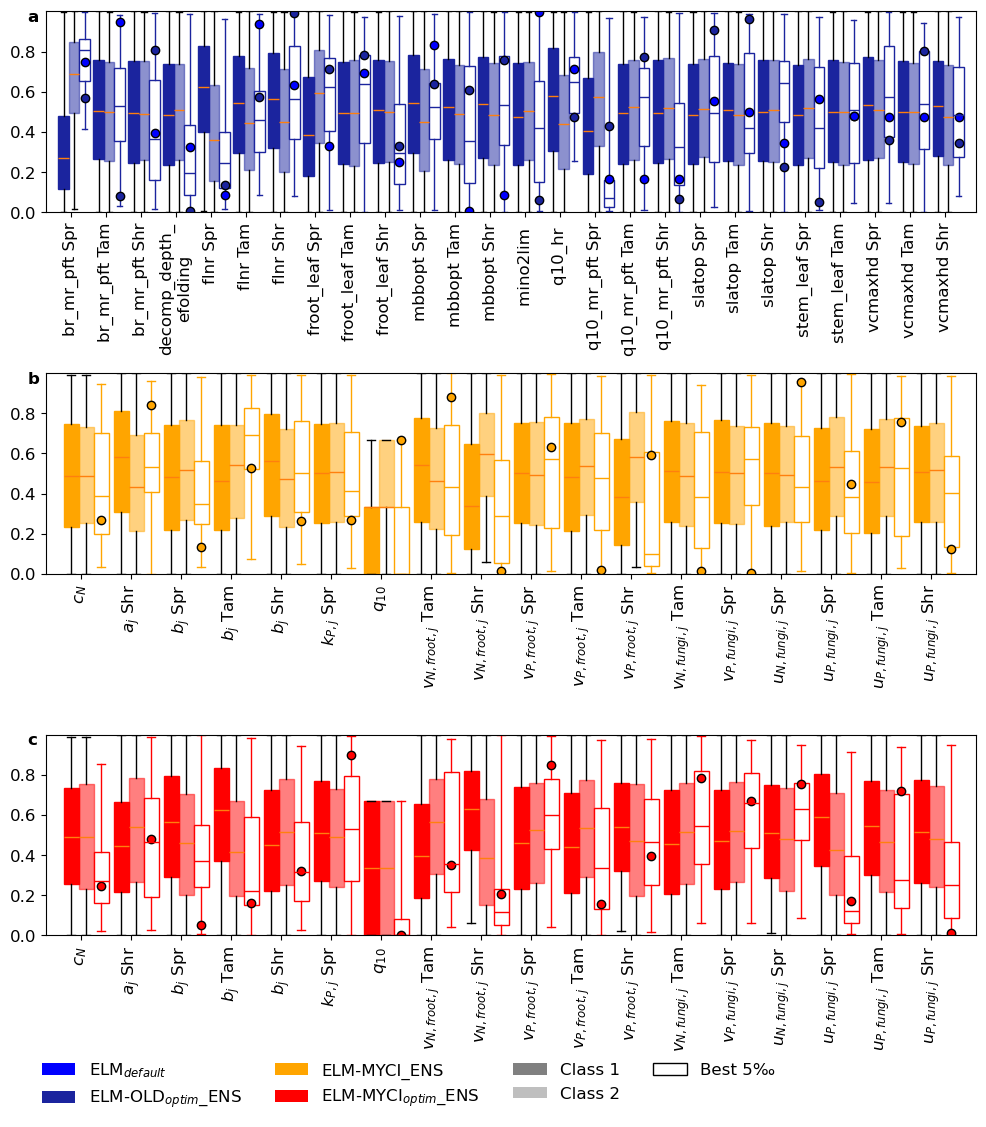

In [7]:
##########################################################################
# Plot the probability distributions of the parameter values
##########################################################################
papernames = {'vmax_froot_n': '$v_{N,froot,j}$', 'vmax_froot_p': '$v_{P,froot,j}$', 
              'vmax_fungi_din': '$v_{N,fungi,j}$', 'vmax_fungi_dip': '$v_{P,fungi,j}$', 
              'vmax_fungi_son': '$u_{N,fungi,j}$', 'vmax_fungi_sop': '$u_{P,fungi,j}$',
              'km_froot_n': '$k_{N,j}$', 'km_froot_p': '$k_{P,j}$', 
              'inh_fungi_a': '$a_j$', 'inh_fungi_b': '$b_j$', 
              'zwt_froot_a': '$h$', 'fungi_cost_n': '$c_N$', 'fungi_cost_p': '$c_P$', 
              'q10_upt': '$q_{10}$', 'swc_opt': r'${\theta}_{opt}$', 
              'alpha_fpg': r'${\alpha}$', 'km_nsc': '$k_{nsc}$'}
pftlabels = {0: '', 2: 'Spr', 3: 'Tam', 11: 'Shr'}
parlist_labels = {}
for prefix in prefix_list:
    parlist_labels[prefix] = []
    for par,pft in parvals_collect[prefix].columns:
        if par == 'zwt_froot_a':
            parlist_labels[prefix].append(papernames[par])
        elif par == 'decomp_depth_efolding':
            parlist_labels[prefix].append('decomp_depth_\nefolding')
        else:
            if prefix == 'UQ_20231118':
                #if pft == 0 or pft == 3:
                parlist_labels[prefix].append(f'{par} {pftlabels[pft]}')
                #else:
                #parlist_labels[prefix].append(pftlabels[pft])
            else:
                parlist_labels[prefix].append(f'{papernames[par]} {pftlabels[pft]}')


fig, axes = plt.subplots(3, 1, figsize = (12, 12), sharex = False, sharey = False)
fig.subplots_adjust(hspace = 0.8)
for i, prefix in enumerate(prefix_list):
    ax = axes.flat[i]
    for j in range(2):
        subset = parvals_collect[prefix].loc[cluster_labels_list[prefix] == j, :]
        bx = ax.boxplot([subset[col] for col in subset.columns], 
                        positions = np.arange(subset.shape[1]) + 0.3*j, 
                        widths = 0.3, patch_artist = True, 
                        whis = [0, 100], showfliers = False)
        for box in bx['boxes']:
            plt.setp(box, color = color_list[i], alpha = 1-j*0.5)

    # best 20
    subset = parvals_collect[prefix].loc[subset_ensemble[prefix], :]
    bx = ax.boxplot([subset[col] for col in subset.columns], 
                    positions = np.arange(subset.shape[1]) + 0.6, 
                    widths = 0.3, patch_artist = True, 
                    whis = [0, 100], showfliers = False)
    for key in ['boxes', 'whiskers', 'caps', 'medians', 'fliers']:
        for element in bx[key]:
            element.set_color(color_list[i])
    for box in bx['boxes']:
        box.set_facecolor('w')

    # best
    ax.plot(np.arange(subset.shape[1]) + 0.3*2, 
            parvals_collect[prefix].loc[subset_ensemble_best[i], :].values, 'o', 
            color = 'k', markerfacecolor = color_list[i])
    ax.set_xticks(np.arange(subset.shape[1])+0.2)
    ax.set_xticklabels(parlist_labels[prefix], rotation = 90)
    ax.set_ylim([0, 1])
    ax.set_yticks(np.arange(0, 0.81, 0.2))
    ax.text(-0.02, 0.95, labs[i], fontdict = {'weight': 'bold'}, transform = ax.transAxes)

    # Add default
    if prefix == 'UQ_20231118':
        ax.plot(np.arange(subset.shape[1]) + 0.3*2, parvals_default.values, 'o', 
                color = 'k', markerfacecolor = 'b')

ax.bar(np.nan, np.nan, color = 'b', label = 'ELM$_{default}$')
for prefix,name,color in zip(prefix_list, name_list, color_list):
    ax.bar(np.nan, np.nan, color = color, label = name)
for alpha, label in zip([1, 0.5], ['Class 1', 'Class 2']):
    ax.bar(np.nan, np.nan, color = 'grey', alpha = alpha, label = label)
ax.bar(np.nan, np.nan, color = 'w', edgecolor = 'k', label = 'Best 5‰')
ax.legend(ncol = 4, bbox_to_anchor = (0.8, -0.55), frameon = False)

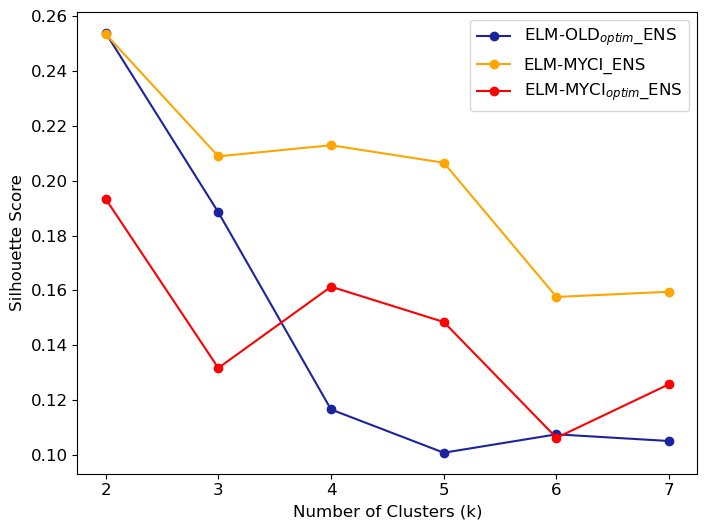

In [8]:
####################################################################################
# Decide number of clusters using silhouette analysis
####################################################################################
# 
# The silhouette score measures how similar each point is to its own cluster compared to 
# other clusters. A higher average silhouette score indicates a better-defined clustering structure.
fig, ax = plt.subplots(figsize = (8, 6))
for i, (prefix, name) in enumerate(zip(prefix_list, name_list)):
    all_data = np.hstack([collect_sims[(prefix, 'mean', 'aco2')], 
                          collect_sims[(prefix, 'mean', 'eco2')], 
                          collect_sims[(prefix, 'slope', 'aco2')], 
                          collect_sims[(prefix, 'slope', 'eco2')]])

    scaler = StandardScaler()
    X_normalized = scaler.fit_transform(all_data)

    silhouette_scores = []
    k_range = range(2, 8)  # Testing number of clusters from 2 to 10

    for k in k_range:
        kmedoids = KMedoids(n_clusters=k, random_state=42)
        labels = kmedoids.fit_predict(X_normalized)
        score = silhouette_score(X_normalized, labels)
        silhouette_scores.append(score)
        # print(f'Number of clusters: {k}, Silhouette Score: {score:.4f}')

    # Plotting the silhouette scores
    ax.plot(k_range, silhouette_scores, marker='o', color = color_list[i], label = name)
    ax.set_xlabel('Number of Clusters (k)')
    ax.set_ylabel('Silhouette Score')
ax.legend()

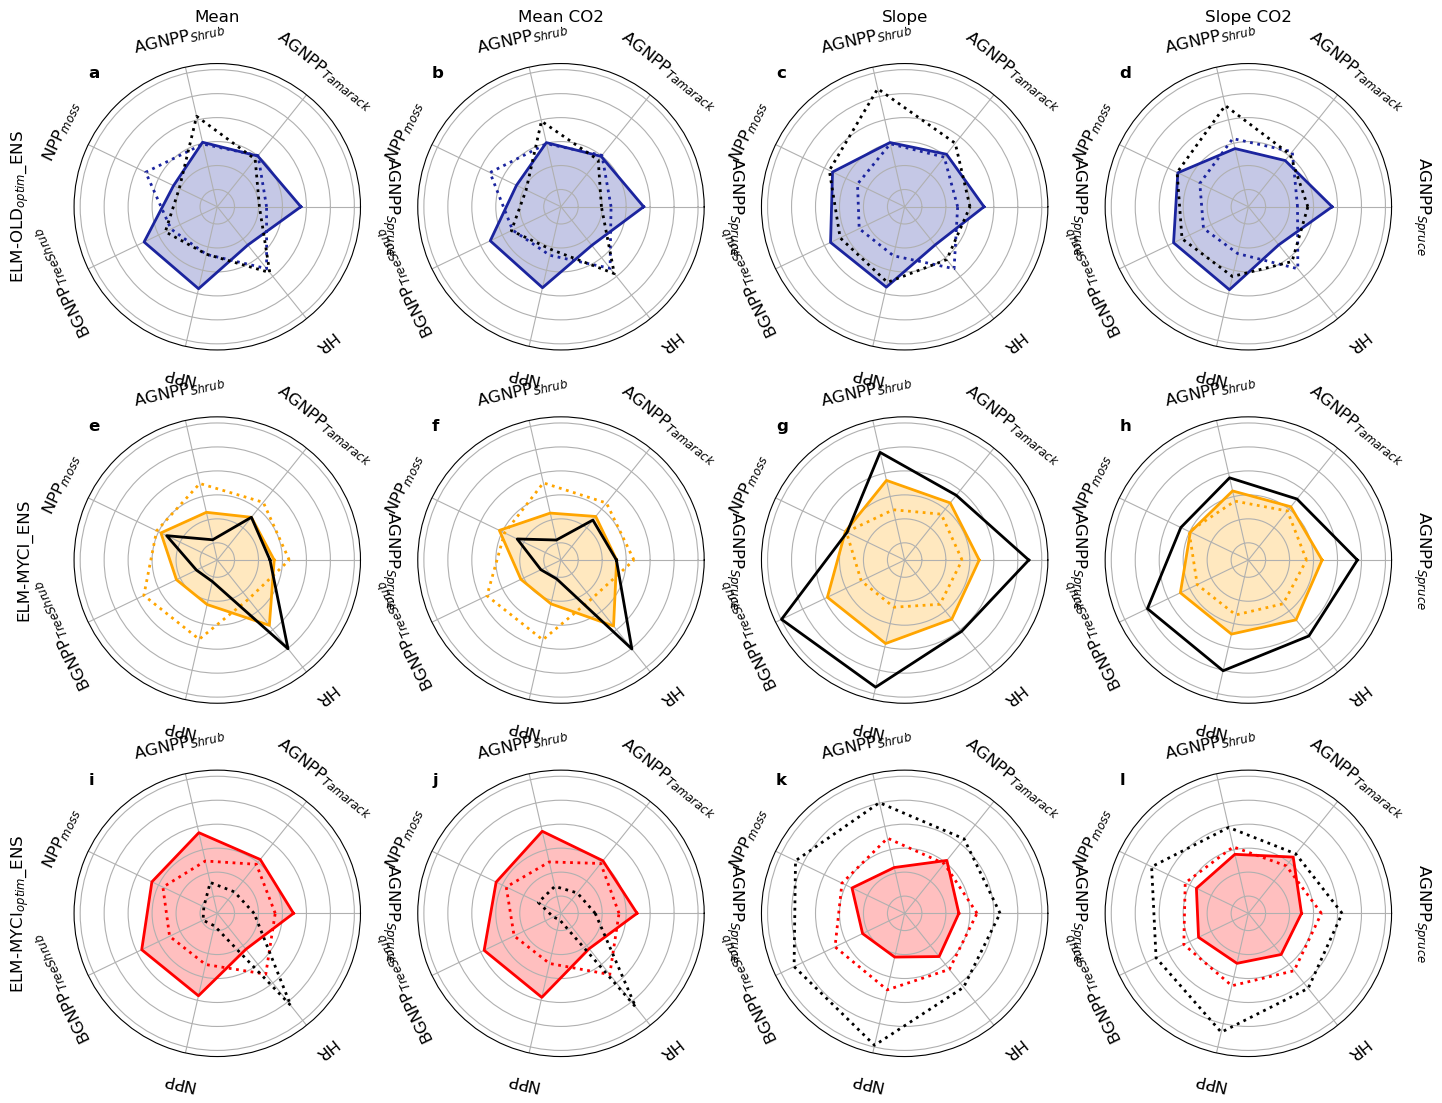

In [9]:
####################################################################################
# Plot the clustering results
####################################################################################
fig, axs = plt.subplots(3, 4, figsize = (17, 13), subplot_kw=dict(polar=True), 
                        sharex = True, sharey = True)
for i, (prefix, name, color) in enumerate(zip(prefix_list, name_list, color_list)):
    all_data = np.hstack([collect_sims[(prefix, 'mean', 'aco2')], 
                          collect_sims[(prefix, 'mean', 'eco2')], 
                          collect_sims[(prefix, 'slope', 'aco2')], 
                          collect_sims[(prefix, 'slope', 'eco2')]])

    scaler = StandardScaler()
    X_normalized = scaler.fit_transform(all_data)

    # Save the cluster labels for later use
    cluster_labels = cluster_labels_list[prefix]

    # Compute the mean vector for each cluster (28 features per cluster)
    cluster_means = np.zeros((K, X_normalized.shape[1]))
    for k in range(K):
        cluster_means[k, :] = np.mean(X_normalized[cluster_labels == k], axis=0)

    # Save the best ensemble member's cluster value (28 values)
    cluster_best = X_normalized[subset_ensemble_best[i]-1, :]
    label_best = cluster_labels[subset_ensemble_best[i]-1]

    # Create radar plots for 4 groups (7 features each)
    num_groups = 4         # 28 features / 7 features per plot
    features_per_plot = 7  # Each radar plot shows 7 features

    # Set up the angles for the radar chart (closing the circle)
    angles = np.linspace(0, 2 * np.pi, features_per_plot, endpoint=False)
    angles = np.concatenate((angles, [angles[0]]))  # Complete the loop

    # Define a color map for the clusters
    ls = ['-',':']
    alpha = [0.25, 0]

    for group in range(num_groups):
        ax = axs[i, group]
        # Get feature indices for this group (e.g., 0-6, 7-13, 14-20, 21-27)
        group_indices = np.arange(group * features_per_plot, (group + 1) * features_per_plot)

        # Plot each cluster's mean for the current group
        for cluster in range(K):
            # Extract the 7 features for this cluster and close the polygon
            values = cluster_means[cluster, group_indices]
            values = np.concatenate((values, [values[0]]))
            ax.plot(angles, values, color=color, ls = ls[cluster],
                    linewidth=2, label=f'Cluster {cluster}')
            ax.fill(angles, values, color=color, ls = ls[cluster], alpha=alpha[cluster])

        values = cluster_best[group_indices]
        values = np.concatenate((values, [values[0]]))
        ax.plot(angles, values, color = 'k', ls = ls[label_best], linewidth = 2)

        # Set feature names as labels (customize as needed)
        ax.set_yticklabels([])
        ax.set_xticks(angles[:-1])
        ax.set_xticklabels([])

        # Manually add labels with rotation so they point outward
        for angle, label in zip(angles[:-1], xticklabels):
            # Convert the angle to degrees for rotation
            angle_deg = np.degrees(angle)
            # Compute a rotation
            rotation = angle_deg - 90
            # Add the label at a radius slightly beyond the maximum plotted radius
            ax.text(angle, 4.5, label,
                    horizontalalignment='center', verticalalignment='center',
                    rotation=rotation, rotation_mode='anchor')

        if i == 0:
            if group == 0:
                ax.set_title(f'Mean', pad = 30)
            elif group == 1:
                ax.set_title(f'Mean CO2', pad = 30)
            elif group == 2:
                ax.set_title(f'Slope', pad = 30)
            else:
                ax.set_title(f'Slope CO2', pad = 30)
        if group == 0:
            ax.set_ylabel(f'{name}', labelpad = 30)

        ax.text(0.05, 0.95, labs[i*4 + group], transform = ax.transAxes, fontdict={'weight':'bold'})

In [10]:
##########################################################################
# Calculate the individual variables' sensitivity score
##########################################################################
def l1_cdf_distance(values1, values2):
    """
    Compute the L1 distance between the empirical CDFs of two 1D samples.
    That is, ∫ |CDF1(x) - CDF2(x)| dx over x in (-∞, +∞).

    values1, values2 : 1D numpy arrays
    Returns a single float, the L1 distance.
    """
    # Create the empirical CDF of the two arrays
    s1 = np.sort(values1)
    cdf1 = np.arange(len(values1)) / len(values1)

    s2 = np.sort(values2)
    cdf2 = np.arange(len(values2)) / len(values2)

    # Interpolate the CDF to the same grid
    s_joint = np.sort(np.concatenate((values1, values2)))
    cdf1_denser = np.interp(s_joint[1:], s1, cdf1)
    cdf2_denser = np.interp(s_joint[1:], s2, cdf2)

    # Integrate the area under curve
    dx = np.diff(s_joint)
    diff_cdf = np.abs(cdf1_denser - cdf2_denser)
    total_area = np.sum(diff_cdf * dx)

    return total_area


def bootstrap_l1_cdf_distance(values, n_bootstrap=1000, random_state=42):
    """
    Calculate a bootstrap sample of the L1 distance between the empirical CDF
    of the original sample and that of bootstrap resamples drawn from it.

    Parameters
    ----------
    values : numpy array of shape (N,)
        The original 1D sample data.
    n_bootstrap : int, optional (default=1000)
        Number of bootstrap replicates.
    random_state : int or None, optional (default=None)
        Random seed for reproducibility.

    Returns
    -------
    bootstrap_distances : numpy array of shape (n_bootstrap,)
        The L1 distances between the original empirical CDF and each bootstrap sample's CDF.
    """
    if random_state is not None:
        np.random.seed(random_state)

    n = len(values)
    bootstrap_distances = np.zeros(n_bootstrap)

    # Use the original sample as the reference for the empirical CDF.
    original_values = values.copy()
    
    for i in range(n_bootstrap):
        # Create a bootstrap resample (sampling with replacement)
        bootstrap_sample = np.random.choice(original_values, size=n, replace=True)
        # Compute L1 distance between the original CDF and the bootstrap sample CDF.
        distance = l1_cdf_distance(original_values, bootstrap_sample)
        bootstrap_distances[i] = distance
        
    return np.percentile(bootstrap_distances, 95)

if False:
    CDF_area_single = {}
    for i, prefix in enumerate(prefix_list):
        parvals = parvals_collect[prefix] # prior distribution of the parameter values
        classes = cluster_labels_list[prefix]

        CDF_area = pd.DataFrame(np.nan, index = parvals.columns, columns = [0,1])
        for k in range(K):
            for col in parvals.columns:
                parval_temp = parvals.loc[classes == k, col]
                dist_L1 = l1_cdf_distance(parvals[col].values, parval_temp.values)
                # ---- additional normalization using bootstrap sampling
                dist_L1_norm = bootstrap_l1_cdf_distance(parval_temp.values)
                CDF_area.loc[col, k] = dist_L1 / dist_L1_norm
        CDF_area_range = np.vstack(
            [CDF_area.max(axis = 1) - CDF_area.mean(axis = 1),
            CDF_area.mean(axis = 1) - CDF_area.min(axis = 1)])
        CDF_area = CDF_area.mean(axis = 1)
        CDF_area_single[prefix] = (CDF_area, CDF_area_range)

    f = open(os.path.join(os.environ['PROJDIR'], 'ELM_Phenology', 'output', 
                        'plot_GSA_CDF_area_single.pkl'), 'wb')
    pickle.dump(CDF_area_single, file = f)
    f.close()

In [11]:
##########################################################################
# Calculate the interactive sensitivity values
##########################################################################
def sensitivity_interaction(theta_i, theta_j, class_labels, c_k, M):
    """
    Compute the sensitivity of theta_i w.r.t. theta_j for class c_k, 
    by binning theta_j into M intervals and comparing each bin's 
    distribution of theta_i to the reference distribution 
    (theta_i for class c_k).

    Parameters
    ----------
    theta_i : array of shape (N,)
        Parameter i values (floats).
    theta_j : array of shape (N,)
        Parameter j values (floats).
    class_labels : array of shape (N,)
        Integer (or categorical) class labels for each sample.
    c_k : int (or the appropriate label type)
        The class of interest whose distribution we use as a reference.
    M : int
        Number of bins for theta_j.

    Returns
    -------
    d_k_i_j : float
        The aggregated sensitivity measure (e.g., the mean of 
        bin-wise L1 distances between distributions).
    """
    # 1. Define bins for theta_j (quantile-based):
    bin_edges = np.quantile(theta_j, np.linspace(0, 1, M+1))

    # 2. Assign each sample to a bin index
    # Note: digitize will produce bin indices in [1, M+1],
    # but the last edge is effectively the top boundary.
    bin_indices = np.digitize(theta_j, bin_edges, right=True)

    # 3. Reference distribution for theta_i in class c_k
    reference_data_i = theta_i[class_labels == c_k]

    # 4. For each bin, estimate distribution F(theta_i | bin)
    #    Compare to F_ref using l1_cdf_distance
    distances = []
    for m in range(1, M+1):
        bin_mask = (bin_indices == m) & (class_labels == c_k)
        bin_data_i = theta_i[bin_mask]

        if len(bin_data_i) == 0:
            # If no data in this bin, skip 
            ## or treat as distance 0
            ## distances.append(0.)
            continue

        dist_m = l1_cdf_distance(bin_data_i, reference_data_i)
        dist_m_normed = bootstrap_l1_cdf_distance(bin_data_i, n_bootstrap=1000, random_state=42)
        distances.append(dist_m/dist_m_normed)

    ### 5. Save some time - calculate within-class bootstrap sample only
    ##dist_m_normed = bootstrap_l1_cdf_distance(reference_data_i, n_bootstrap=1000, random_state=42)
    ##distances = np.array(distances) / dist_m_normed

    # 6. Aggregate distances across bins
    d_k_i_j = np.mean(distances)
    
    return d_k_i_j


# Number of bins to divide up theta_j
M = 20

if False:
    # This takes more than 1 hour!
    # No increased speed running on a server
    CDF_area_interactive = {}
    for i, prefix in enumerate(prefix_list):
        parvals = parvals_collect[prefix]
        classes = cluster_labels_list[prefix]

        CDF_area_interactive[prefix] = pd.DataFrame(np.nan, index = parvals.columns, 
                                                    columns = parvals.columns)
        for col,col2 in tqdm(it.product(parvals.columns, parvals.columns)):
            if col == col2:
                continue
            dist_k = []
            for k in range(K):
                sens = sensitivity_interaction(parvals[col], parvals[col2], classes, k, M)
                dist_k.append(sens)
            CDF_area_interactive[prefix].loc[col, col2] = np.mean(dist_k)

    f = open(os.path.join(os.environ['PROJDIR'], 'ELM_Phenology', 'output', 
                        'plot_GSA_CDF_area_interactive.pkl'), 'wb')
    pickle.dump(CDF_area_interactive, file = f)
    f.close()

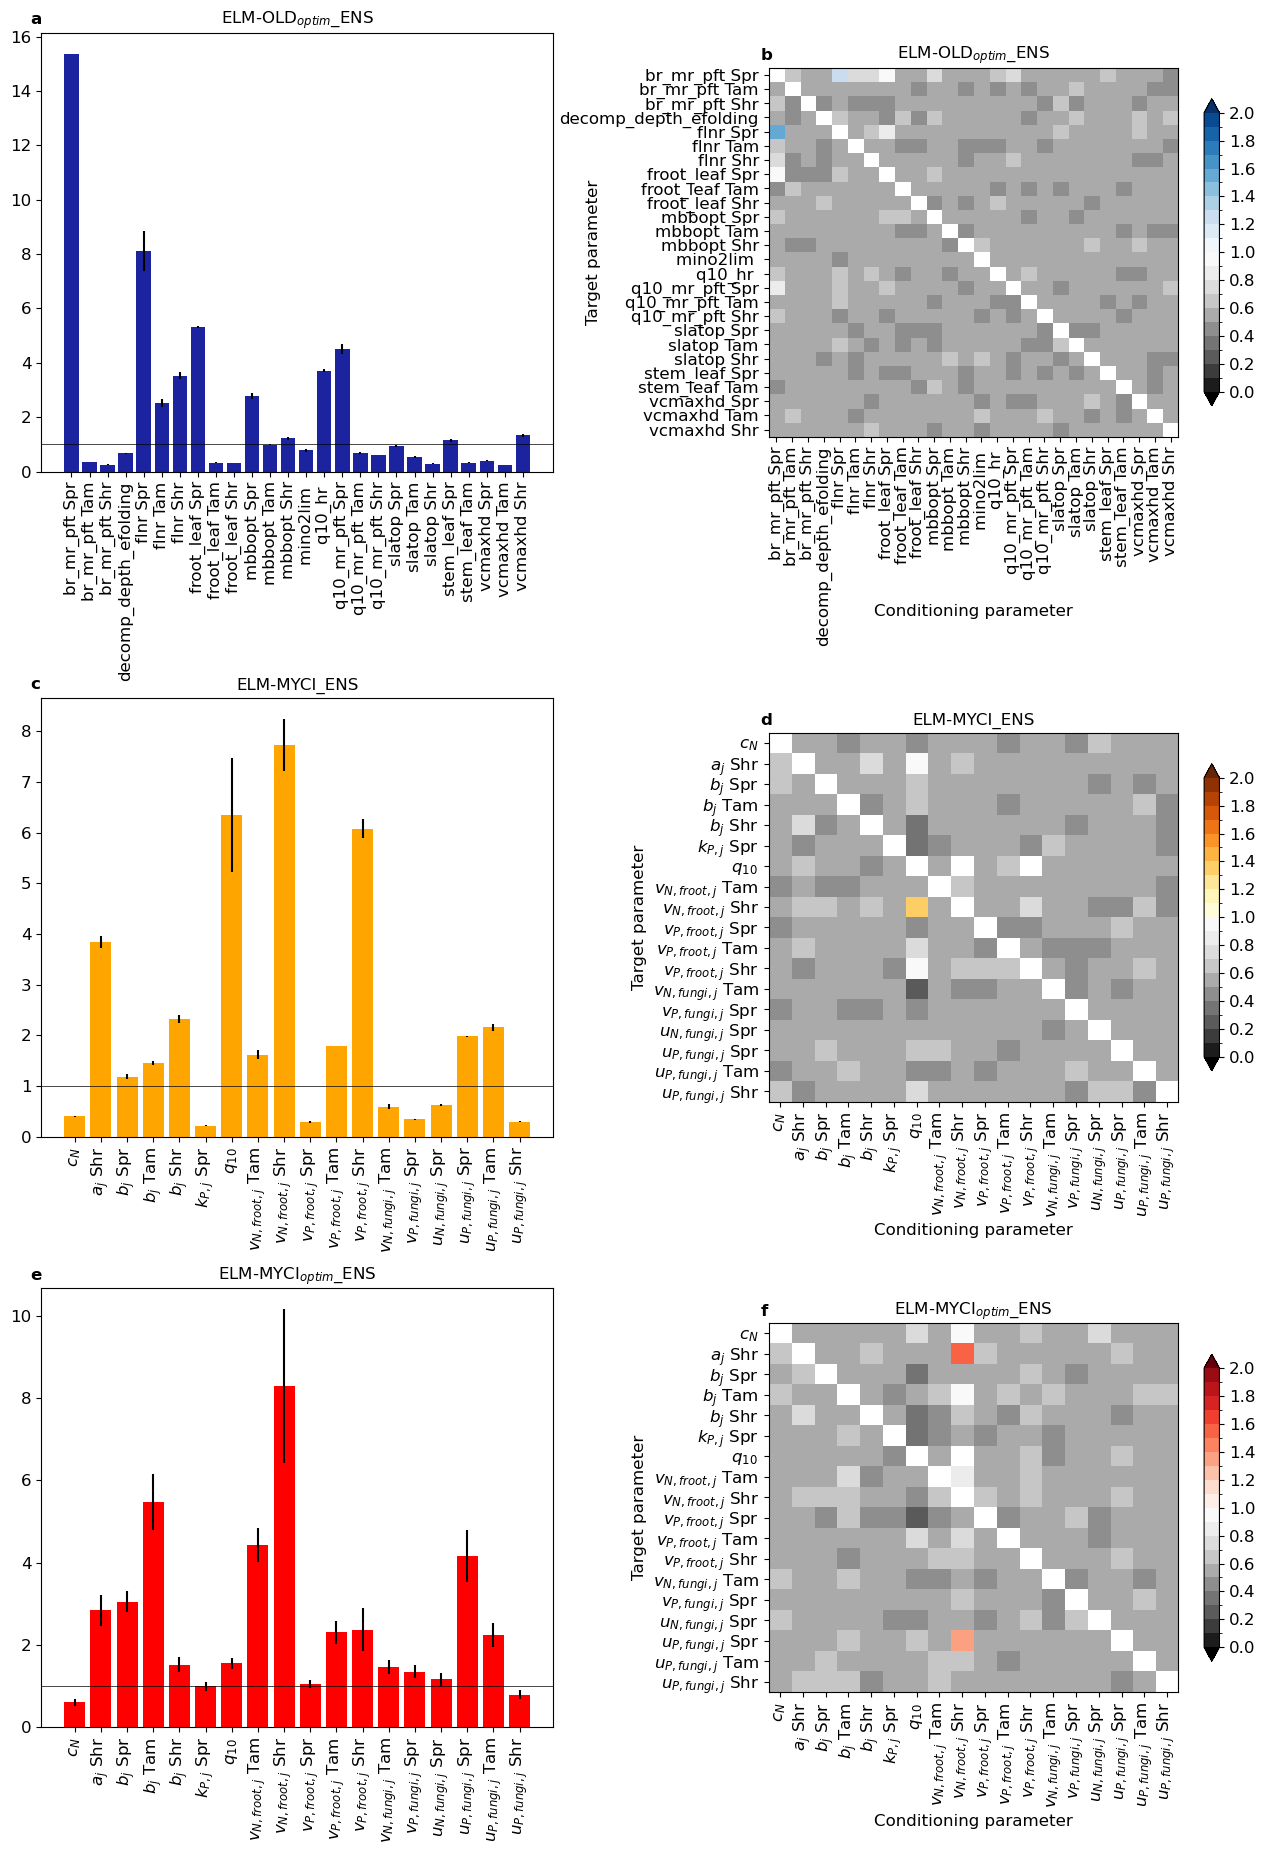

In [12]:
f = open(os.path.join(os.environ['PROJDIR'], 'ELM_Phenology', 'output', 
                      'plot_GSA_CDF_area_single.pkl'), 'rb')
CDF_area_single = pickle.load(f)
f.close()

f = open(os.path.join(os.environ['PROJDIR'], 'ELM_Phenology', 'output', 
                      'plot_GSA_CDF_area_interactive.pkl'), 'rb')
CDF_area_interactive = pickle.load(f)
f.close()


# Set norm
levels = np.linspace(0., 2, 21)
norm = BoundaryNorm(levels, ncolors=256, extend='both')

# Calculate the segmentation of colormap to be applied later
split_val = 1.0
split_idx = np.searchsorted(levels, split_val)

n_low = 128 #int((split_idx)/len(levels) * 256)
n_high = 256 - n_low #len(levels) - split_idx - 1


# Plot
fig = plt.figure(figsize=(16, 22))
gs = gridspec.GridSpec(5, 2, height_ratios=[1, 0.25, 1, 0.08, 1], hspace=0.2, wspace=0.42)
axes = np.empty([3, 2], dtype = object)
for i,j in it.product(range(3), range(2)):
    axes[i,j] = fig.add_subplot(gs[i*2,j])

for i, prefix in enumerate(prefix_list):
    ticks = [p.replace('\n', '') for p in parlist_labels[prefix]]

    # Single sensitivity
    ax = axes[i, 0]

    parvals = parvals_collect[prefix]
    CDF_area = CDF_area_single[prefix][0]
    CDF_area_range = CDF_area_single[prefix][1]

    bx = ax.bar(height = CDF_area.values, x = np.arange(len(CDF_area)), 
                color = color_list[i])
    ax.errorbar(np.arange(len(CDF_area)), CDF_area, 
                yerr = CDF_area_range, ls = '', color = 'k')

    ax.axhline(1, color = 'k', lw = 0.5)
    ax.set_xticks(np.arange(len(CDF_area)))
    ax.set_xticklabels(ticks, rotation = 90)
    ax.text(-0.02, 1.02, labs[i*2], fontdict = {'weight': 'bold'}, transform = ax.transAxes)
    ax.set_title(name_list[i])

    # Interactive sensitivity
    ax = axes[i, 1]

    temp = CDF_area_interactive[prefix]

    if prefix == 'UQ_20231118':
        top = 'Blues'
    elif prefix == 'UQ_20240107':
        top = 'YlOrBr'
    else:
        top = 'Reds'

    # Create two colormaps
    orange_cmap = plt.get_cmap('Greys_r', n_low)
    blue_cmap = plt.get_cmap(top, n_high)

    # Combine colors from both
    combined_colors = np.vstack([
        orange_cmap(np.linspace(0, 1, n_low)),  # orange side (avoid too light colors)
        blue_cmap(np.linspace(0, 1, n_high))    # blue side
    ])

    # Create new combined colormap
    custom_cmap = ListedColormap(combined_colors)


    cf = ax.imshow(temp, cmap = custom_cmap, norm = norm, aspect = 0.9)

    ax.set_xticks(np.arange(temp.shape[0]))
    ax.set_xticklabels(ticks, rotation = 90)

    ax.set_yticks(np.arange(temp.shape[1]))
    ax.set_yticklabels(ticks)

    ax.text(-0.02, 1.02, labs[i*2+1], fontdict = {'weight': 'bold'}, transform = ax.transAxes)
    ax.set_title(name_list[i])

    if i == 0:
        ax.set_xlabel('Conditioning parameter', labelpad = -30)
        ax.set_ylabel('Target parameter', labelpad = -30)
    else:
        ax.set_xlabel('Conditioning parameter')
        ax.set_ylabel('Target parameter')

    cbar = plt.colorbar(cf, ax = ax, orientation = 'vertical', shrink = 0.7)
    cbar.set_ticks(levels[::2], minor = [])